Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

Dataset cleaning

In [3]:
# train = pd.read_csv('C:/Users/iahas/OneDrive/Documents/New ML projects/COMP 6721/CUSTOMER RETENTION STRATEGIES IN E-COMMERCE/Train_Data.csv')
# test  = pd.read_csv('C:/Users/iahas/OneDrive/Documents/New ML projects/COMP 6721/CUSTOMER RETENTION STRATEGIES IN E-COMMERCE/Test_Data.csv')

train = pd.read_csv('./CUSTOMER RETENTION STRATEGIES IN E-COMMERCE/Train_Data.csv')
test = pd.read_csv('./CUSTOMER RETENTION STRATEGIES IN E-COMMERCE/Test_Data.csv')

print('Raw shapes:', train.shape, test.shape)

print('\nStarting the dataset cleaning:')
# Checking for any missing values across all features in the training set
print('\nMissing values found in the training dataset:')
print(train.isnull().sum())

# We will impute missing numerical values using the median to ensure data consistency
num_cols = ['esent', 'eopenrate', 'eclickrate', 'avgorder', 'ordfreq']
for col in num_cols:
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)
    test[col]  = test[col].fillna(median_val)

# Dropping the rows that are still missing dates
train = train.dropna(subset=['created', 'firstorder', 'lastorder'])
test  = test.dropna(subset=['created', 'firstorder', 'lastorder'])

# We will use the built in datetime found in pandas as it is easier to work with
date_cols = ['created', 'firstorder', 'lastorder']
for col in date_cols:
    train[col] = pd.to_datetime(train[col], dayfirst=True, format='mixed', errors='coerce')
    test[col]  = pd.to_datetime(test[col],  dayfirst=True, format='mixed', errors='coerce')

# We will identify any dates that failed to parse and were converted to NaT, and remove the collums
print('Unparseable dates turned into NaT:')
for col in date_cols:
    print(f'  train[{col}]: {train[col].isna().sum()} | test[{col}]: {test[col].isna().sum()}')
train = train.dropna(subset=date_cols)
test  = test.dropna(subset=date_cols)
print(f'\nShapes after dropping bad dates: train={train.shape}, test={test.shape}')

# Establishing a reference point to calculate the recency of customer activity
reference_date = train['lastorder'].max()

# We will engineer new features representing customer tenure and time since last purchase
for df in [train, test]:
    df['tenure_days']     = (df['lastorder']  - df['created']).dt.days
    df['days_to_first']   = (df['firstorder'] - df['created']).dt.days
    df['days_since_last'] = (reference_date   - df['lastorder']).dt.days

# Dropping the collumns the models do not need, we get:
drop_cols = ['custid', 'created', 'firstorder', 'lastorder']
train = train.drop(columns=drop_cols)
test  = test.drop(columns=drop_cols)

# Reviewing the statistical distribution of our cleaned features
print('\nStatistical distribution of our cleaned features')
print(train.describe().round(2))

print('\nFinal columns')
print(train.columns.tolist())
print('\nCleaning complete. Shapes:', train.shape, test.shape)

Raw shapes: (30801, 15) (38, 14)

Starting the dataset cleaning:

Missing values found in the training dataset:
custid        20
retained       0
created       20
firstorder    20
lastorder     20
esent          0
eopenrate      0
eclickrate     0
avgorder       0
ordfreq        0
paperless      0
refill         0
doorstep       0
favday         0
city           0
dtype: int64
Unparseable dates turned into NaT:
  train[created]: 0 | test[created]: 0
  train[firstorder]: 12 | test[firstorder]: 0
  train[lastorder]: 23 | test[lastorder]: 0

Shapes after dropping bad dates: train=(30758, 15), test=(38, 14)

Statistical distribution of our cleaned features
       retained     esent  eopenrate  eclickrate  avgorder   ordfreq  \
count  30758.00  30758.00   30758.00    30758.00  30758.00  30758.00   
mean       0.79     28.14      25.56        5.67     61.85      0.04   
std        0.40     16.75      29.56       10.57     40.95      0.10   
min        0.00      0.00       0.00        0.00   

Data Preprocessing (Cannot rerun only cell, rerun all when needed)

In [4]:
# We will encode the categorical columns favday and city into a separate 0/1 column for each unique value found
train = pd.get_dummies(train, columns=['favday', 'city'], drop_first=True)
test  = pd.get_dummies(test,  columns=['favday', 'city'], drop_first=True)

# We will align the columns so that test has the exact same structure as train so that if a city or day appears in train but not in test, test gets a 0 column for it
train, test = train.align(test, join='left', axis=1, fill_value=0)

print('Shape after encoding:', train.shape, test.shape)

# Separating our features from the target variable
TARGET   = 'retained'
FEATURES = [col for col in train.columns if col != TARGET]

X = train[FEATURES]
y = train[TARGET]

# Test set has no real labels so we only used for final predictions only
X_test_final = test[FEATURES]

print(f'\nFeatures used ({len(FEATURES)}):')
print(FEATURES)

# Test set has no labels so we carve out a validation set from training data to use for model evaluation instead
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTraining samples   : {X_train.shape[0]}')
print(f'Validation samples : {X_val.shape[0]}')

# We will fit the scaler on training data only & apply the same scale to both validation and test to prevent data leakage
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test_final)

print(f'\nPreprocessing complete.')
print(f'   X_train : {X_train_scaled.shape}')
print(f'   X_val   : {X_val_scaled.shape}')
print(f'   X_test  : {X_test_scaled.shape}')
print(f'   Retention rate — train: {y_train.mean():.1%} | val: {y_val.mean():.1%}')

Shape after encoding: (30758, 21) (38, 21)

Features used (20):
['esent', 'eopenrate', 'eclickrate', 'avgorder', 'ordfreq', 'paperless', 'refill', 'doorstep', 'tenure_days', 'days_to_first', 'days_since_last', 'favday_Monday', 'favday_Saturday', 'favday_Sunday', 'favday_Thursday', 'favday_Tuesday', 'favday_Wednesday', 'city_BOM', 'city_DEL', 'city_MAA']

Training samples   : 24606
Validation samples : 6152

Preprocessing complete.
   X_train : (24606, 20)
   X_val   : (6152, 20)
   X_test  : (38, 20)
   Retention rate — train: 79.5% | val: 79.5%


K-Means Clustering: Plot elbow curve

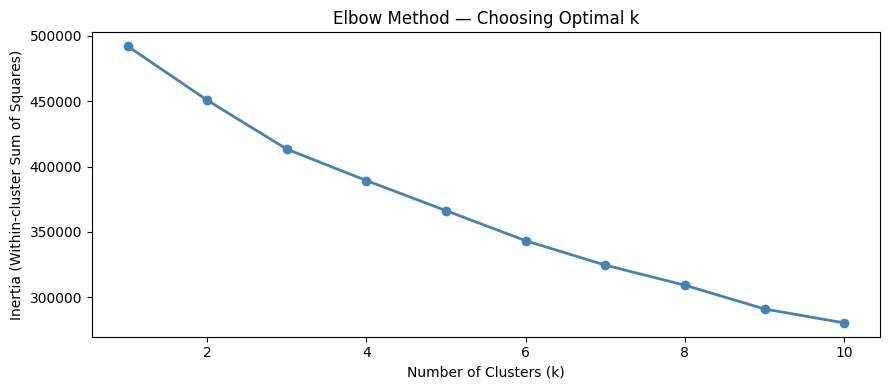

Observation: Inspect the curve above and identify where it bends.
That bend point is the optimal k value we will use below.


In [5]:
# We will use the elbow method to identify the optimal number of clusters by measuring how much variance is explained as we increase k
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_scaled)
    inertia.append(km.inertia_)

# Plotting the elbow curve to visually identify where adding more clusters stops providing meaningful improvement
plt.figure(figsize=(9, 4))
plt.plot(K_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title('Elbow Method — Choosing Optimal k')
plt.tight_layout()
plt.show()

print('Observation: Inspect the curve above and identify where it bends.')
print('That bend point is the optimal k value we will use below.')

K-Means Clustering: Decide number of clusters

In [6]:
# We will set k based on the elbow plot above — adjust this value if needed
K = 3

# Fitting the final K-Means model on our scaled training data
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
X_train_clusters = kmeans.fit_predict(X_train_scaled)
X_val_clusters   = kmeans.predict(X_val_scaled)

# Adding the cluster labels back to a copy of the training data for analysis
train_clustered = X_train.copy()
train_clustered['cluster']  = X_train_clusters
train_clustered['retained'] = y_train.values

print(f'K-Means fitted with k={K}')
print('\nCluster distribution:')
print(train_clustered['cluster'].value_counts().sort_index())

K-Means fitted with k=3

Cluster distribution:
cluster
0    7039
1    9824
2    7743
Name: count, dtype: int64


K value chosen = 3, as 4 gave us a cluster of 900 and another of 9000 -> uneven split, while 3 gives a very even split

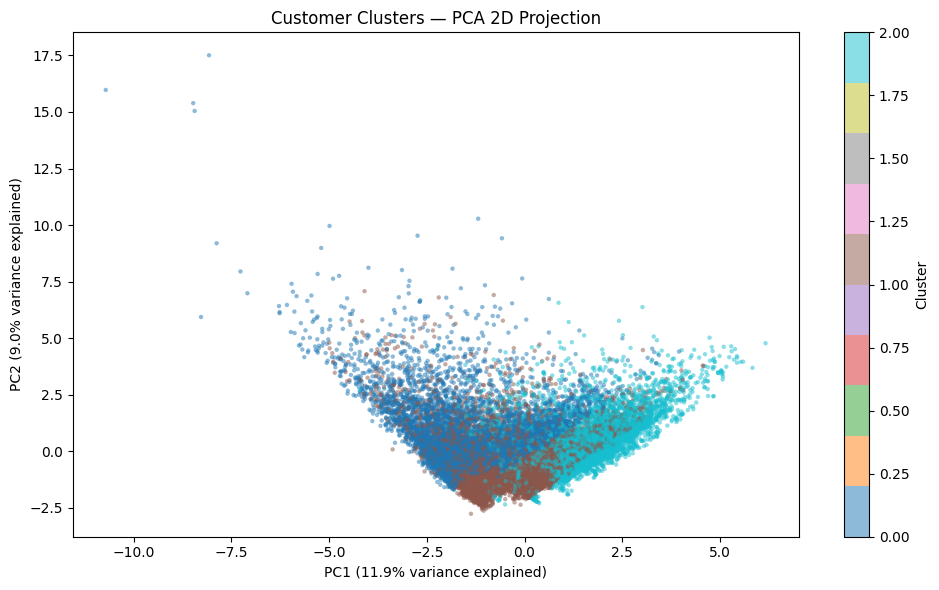

In [7]:

# Reducing our 20 features down to 2 dimensions using PCA to plot human readable clusters
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_train_scaled)
explained = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    coords[:, 0], coords[:, 1],
    c=X_train_clusters, cmap='tab10', alpha=0.5, s=10, edgecolors='none'
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({explained[0]:.1%} variance explained)')
plt.ylabel(f'PC2 ({explained[1]:.1%} variance explained)')
plt.title('Customer Clusters — PCA 2D Projection')
plt.tight_layout()
plt.show()

In [8]:
# We will examine the avg value of each feature to understand customer behaviour in each cluster
cluster_profile = train_clustered.groupby('cluster')[FEATURES + ['retained']].mean().round(3)
cluster_profile['count'] = train_clustered.groupby('cluster').size()

print('=== Cluster Profiles ===')
print(cluster_profile.T.to_string())

=== Cluster Profiles ===
cluster                  0         1         2
esent               26.985    29.175    27.631
eopenrate           21.787    23.387    31.638
eclickrate           4.538     4.461     8.089
avgorder            66.548    60.746    58.452
ordfreq              0.041     0.034     0.039
paperless            0.475     0.647     0.810
refill               0.088     0.115     0.075
doorstep             0.007     0.010     0.103
tenure_days        239.342   115.519    54.633
days_to_first       69.656    37.340    21.577
days_since_last   4566.671  4424.117  4276.278
favday_Monday        0.263     0.223     0.177
favday_Saturday      0.001     0.000     0.127
favday_Sunday        0.002     0.000     0.064
favday_Thursday      0.171     0.182     0.159
favday_Tuesday       0.208     0.230     0.211
favday_Wednesday     0.186     0.150     0.137
city_BOM             0.000     0.945     0.000
city_DEL             0.994     0.000     0.001
city_MAA             0.001     0.00

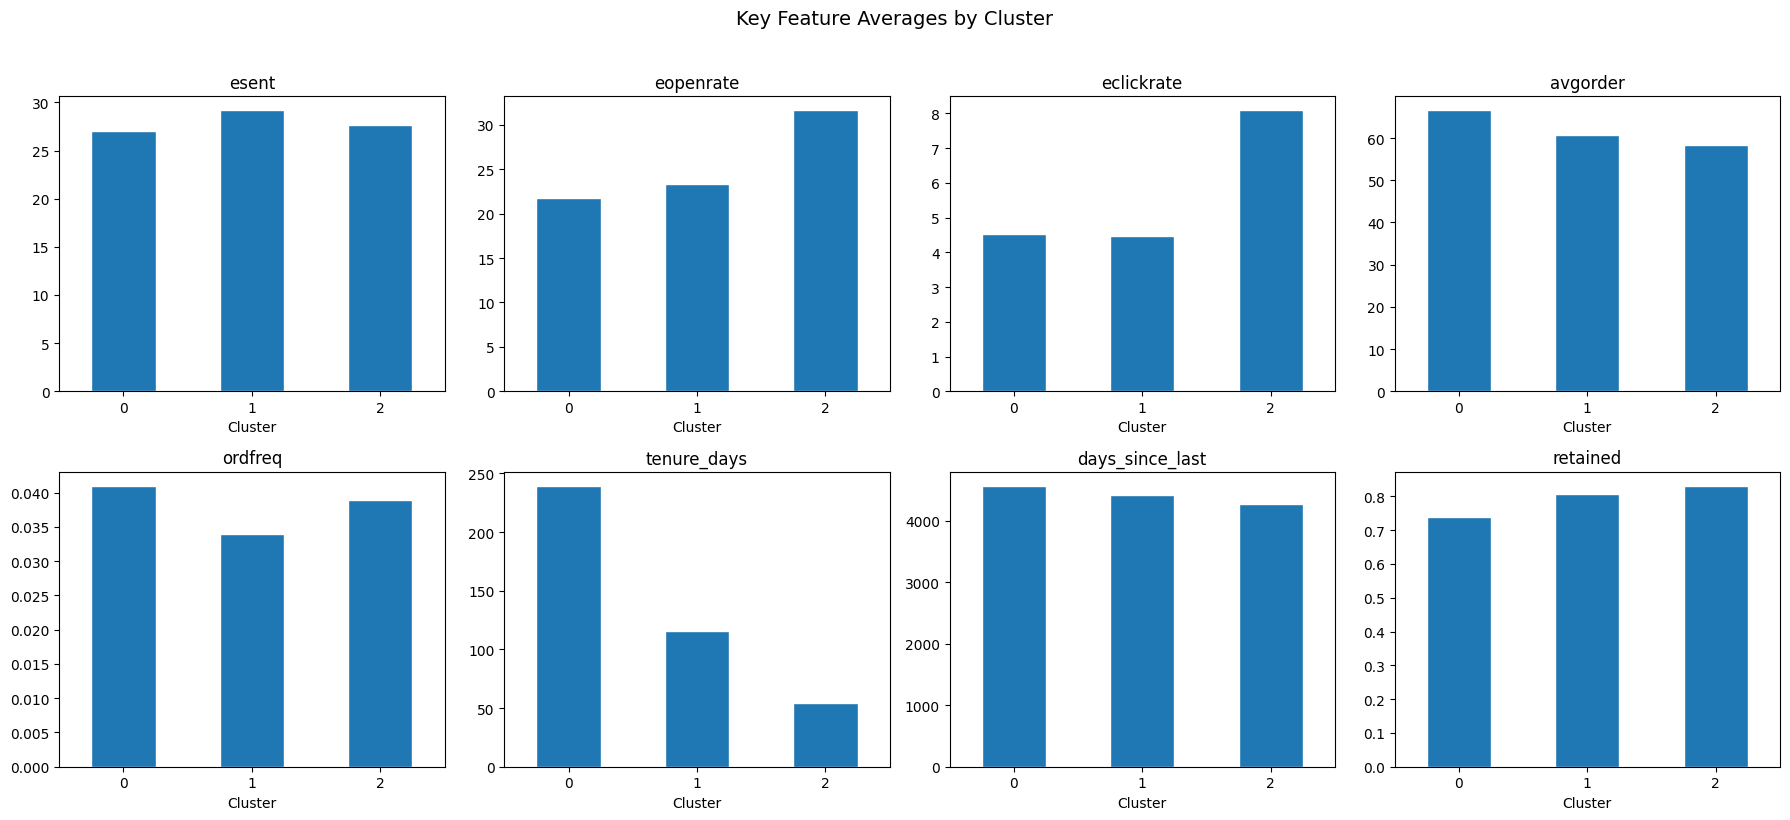

In [9]:
# We will focus on the most business-relevant features
key_features = ['esent', 'eopenrate', 'eclickrate', 'avgorder', 'ordfreq',
                'tenure_days', 'days_since_last', 'retained']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    cluster_profile[feat].plot(kind='bar', ax=axes[i], edgecolor='white', colormap='tab10')
    axes[i].set_title(feat)
    axes[i].set_xlabel('Cluster')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

plt.suptitle('Key Feature Averages by Cluster', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# The clusters seem primarily driven by city in this data set, with ssmall differences in tenure, email engagement, and spending behaviour
cluster_labels = {
    0: 'Veteran Low-Engagement Customers',
    1: 'Mid-Tenure Moderate Customers',
    2: 'New High-Engagement Customers'
}

train_clustered['cluster_name'] = train_clustered['cluster'].map(cluster_labels)

print('Cluster labels assigned:')
print(train_clustered['cluster_name'].value_counts())

Cluster labels assigned:
cluster_name
Mid-Tenure Moderate Customers       9824
New High-Engagement Customers       7743
Veteran Low-Engagement Customers    7039
Name: count, dtype: int64


In [11]:
# =========================
# SUPERVISED LEARNING PART
# =========================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# Define the models
models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=2000
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    )
}

results = {}
fitted_models = {}

for name, model in models.items():
    print("=" * 70)
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    fitted_models[name] = model
    
    # Predict class labels
    y_pred = model.predict(X_val_scaled)
    
    # Predict probabilities / scores for ROC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_val_scaled)[:, 1]
    else:
        y_score = model.decision_function(X_val_scaled)
    
    # Compute metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_val, y_score)
    
    results[name] = {
        "model": model,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc_auc,
        "y_pred": y_pred,
        "y_score": y_score
    }
    
    # Print metrics
    print(f"\n{name} Performance on Validation Set")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred, zero_division=0))


Training Logistic Regression...

Logistic Regression Performance on Validation Set
Accuracy : 0.9441
Precision: 0.9575
Recall   : 0.9728
F1-score : 0.9651
ROC-AUC  : 0.9657

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1264
           1       0.96      0.97      0.97      4888

    accuracy                           0.94      6152
   macro avg       0.92      0.90      0.91      6152
weighted avg       0.94      0.94      0.94      6152


Training Random Forest...

Random Forest Performance on Validation Set
Accuracy : 0.9651
Precision: 0.9655
Recall   : 0.9914
F1-score : 0.9783
ROC-AUC  : 0.9831

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.86      0.91      1264
           1       0.97      0.99      0.98      4888

    accuracy                           0.97      6152
   macro avg       0.96      0.93      0.94      6152
weighted avg     

In [12]:
# ===============
# COMPARE MODELS
# ===============

results_df = pd.DataFrame({
    name: {
        "Accuracy": vals["accuracy"],
        "Precision": vals["precision"],
        "Recall": vals["recall"],
        "F1 Score": vals["f1"],
        "ROC-AUC": vals["roc_auc"]
    }
    for name, vals in results.items()
}).T.sort_values(by="F1 Score", ascending=False)

display(results_df.round(4))

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Random Forest,0.9651,0.9655,0.9914,0.9783,0.9831
Logistic Regression,0.9441,0.9575,0.9728,0.9651,0.9657


<Figure size 500x400 with 0 Axes>

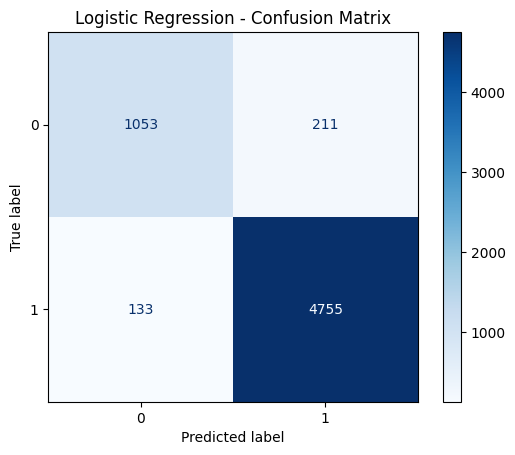

<Figure size 500x400 with 0 Axes>

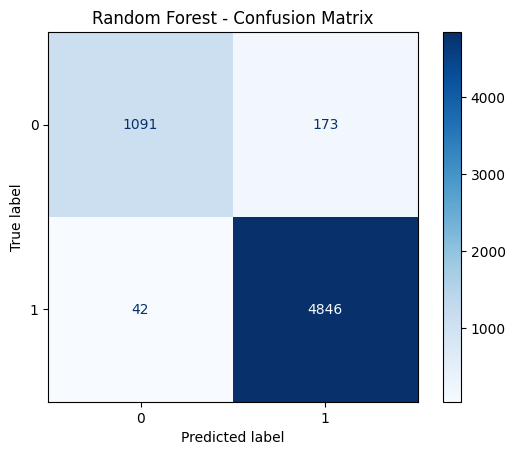

In [13]:
# ===================
# CONFUSION MATRICES
# ===================

for name, vals in results.items():
    cm = confusion_matrix(y_val, vals["y_pred"])
    
    plt.figure(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{name} - Confusion Matrix")
    plt.grid(False)
    plt.show()

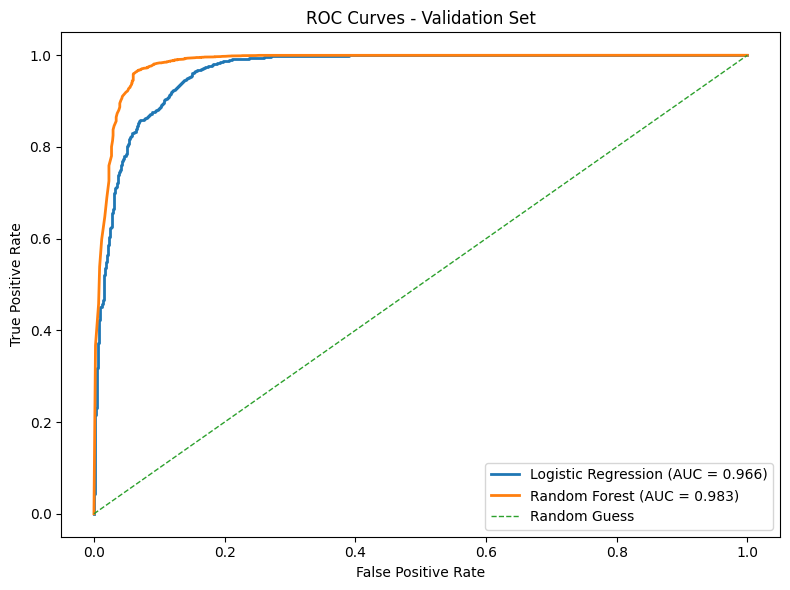

In [14]:
# ============
# ROC CURVES
# ============

plt.figure(figsize=(8, 6))

for name, vals in results.items():
    fpr, tpr, _ = roc_curve(y_val, vals["y_score"])
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {vals['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Validation Set")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# =========================
# BEST MODEL SELECTION
# =========================

best_model_name = results_df.index[0]
best_model = fitted_models[best_model_name]

print(f"Best model based on F1 Score: {best_model_name}")
print("\nBest model metrics:")
print(results_df.loc[best_model_name].round(4))

Best model based on F1 Score: Random Forest

Best model metrics:
Accuracy     0.9651
Precision    0.9655
Recall       0.9914
F1 Score     0.9783
ROC-AUC      0.9831
Name: Random Forest, dtype: float64


In [17]:
# =============================
# FINAL PREDICTION ON TEST SET  (NOT SURE IF THIS IS NEEDED, BUT HERE IT IS ANYWAY ¯\_(ツ)_/¯)
# =============================

test_pred = best_model.predict(X_test_scaled)

print("Final test predictions generated successfully.\n")
print(f"Best model used for final prediction: {best_model_name}")

final_predictions = pd.DataFrame({
    "Predicted_retained": test_pred
})
final_predictions.to_csv("final_test_predictions.csv", index=False)
print("Saved: final_test_predictions.csv")

Final test predictions generated successfully.

Best model used for final prediction: Random Forest
Saved: final_test_predictions.csv


In [18]:
# =====================
# RECOMMENDATION LOGIC
# =====================

# Map each cluster to a recommendation strategy
recommendation_map = {
    'Veteran Low-Engagement Customers': {
        'recommendation': 'Send retention emails and discount offers',
        'reason': 'These customers have been around for a long time but show lower engagement, so retention-focused actions make the most sense.'
    },
    'Mid-Tenure Moderate Customers': {
        'recommendation': 'Offer personalized bundles and cross-sell products',
        'reason': 'These customers show moderate activity, so targeted product suggestions may increase order frequency and spending.'
    },
    'New High-Engagement Customers': {
        'recommendation': 'Recommend premium products and loyalty rewards',
        'reason': 'These customers are highly engaged, so upselling and loyalty incentives are suitable.'
    }
}

cluster_recommendation_summary = pd.DataFrame({
    'Cluster Name': list(recommendation_map.keys()),
    'Recommended Action': [recommendation_map[k]['recommendation'] for k in recommendation_map],
    'Reason': [recommendation_map[k]['reason'] for k in recommendation_map]
})

print("=== Cluster Recommendation Summary ===")
display(cluster_recommendation_summary)

=== Cluster Recommendation Summary ===


,Cluster Name,Recommended Action,Reason
0,Veteran Low-Engagement Customers,Send retention emails and discount offers,These customers have been around for a long ti...
1,Mid-Tenure Moderate Customers,Offer personalized bundles and cross-sell prod...,"These customers show moderate activity, so tar..."
2,New High-Engagement Customers,Recommend premium products and loyalty rewards,"These customers are highly engaged, so upselli..."
